In [4]:
# ================================================
# CELL 1 — IMPORT LIBRARY & LOAD DATA
# ================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import joblib

# Machine Learning
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Evaluasi
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

warnings.filterwarnings('ignore')
print("✅ Library berhasil diimport!")

# ================================================
# LOAD DATA HASIL PREPROCESSING
# ================================================
X_train = pd.read_csv('../data/processed/X_train.csv')
X_test  = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_test  = pd.read_csv('../data/processed/y_test.csv').squeeze()

print(f"\n✅ Data berhasil dimuat!")
print(f"   X_train : {X_train.shape}")
print(f"   X_test  : {X_test.shape}")
print(f"   y_train : {y_train.shape}")
print(f"   y_test  : {y_test.shape}")

✅ Library berhasil diimport!

✅ Data berhasil dimuat!
   X_train : (9600, 21)
   X_test  : (2400, 21)
   y_train : (9600,)
   y_test  : (2400,)


In [5]:
# ================================================
# CELL 2 — FUNGSI EVALUASI (DIPAKAI BERULANG)
# ================================================

def evaluasi_model(nama_model, model, X_test, y_test):
    """
    Fungsi untuk evaluasi performa model
    secara lengkap & konsisten
    """
    y_pred = model.predict(X_test)

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted')
    rec  = recall_score(y_test, y_pred, average='weighted')
    f1   = f1_score(y_test, y_pred, average='weighted')

    print("=" * 55)
    print(f"  📊 HASIL EVALUASI: {nama_model}")
    print("=" * 55)
    print(f"  Accuracy  : {acc:.4f}  ({acc*100:.2f}%)")
    print(f"  Precision : {prec:.4f} ({prec*100:.2f}%)")
    print(f"  Recall    : {rec:.4f}  ({rec*100:.2f}%)")
    print(f"  F1-Score  : {f1:.4f}  ({f1*100:.2f}%)")
    print("=" * 55)
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    return {
        'model_name' : nama_model,
        'accuracy'   : acc,
        'precision'  : prec,
        'recall'     : rec,
        'f1_score'   : f1,
        'y_pred'     : y_pred
    }


def plot_confusion_matrix(nama_model, y_test, y_pred, labels):
    """
    Fungsi untuk visualisasi confusion matrix
    """
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=labels
    )

    fig, ax = plt.subplots(figsize=(8, 6))
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'Confusion Matrix — {nama_model}',
                 fontweight='bold', fontsize=13)
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.savefig(
        f'../docs/cm_{nama_model.lower().replace(" ", "_")}.png',
        dpi=150, bbox_inches='tight'
    )
    plt.show()


print("✅ Fungsi evaluasi siap digunakan!")

✅ Fungsi evaluasi siap digunakan!


🌳 Training Decision Tree...
✅ Training selesai!
  📊 HASIL EVALUASI: Decision Tree
  Accuracy  : 0.2612  (26.12%)
  Precision : 0.2604 (26.04%)
  Recall    : 0.2612  (26.12%)
  F1-Score  : 0.2595  (25.95%)

Classification Report:
              precision    recall  f1-score   support

           0       0.27      0.29      0.28       582
           1       0.25      0.27      0.26       611
           2       0.28      0.29      0.28       607
           3       0.25      0.19      0.21       600

    accuracy                           0.26      2400
   macro avg       0.26      0.26      0.26      2400
weighted avg       0.26      0.26      0.26      2400



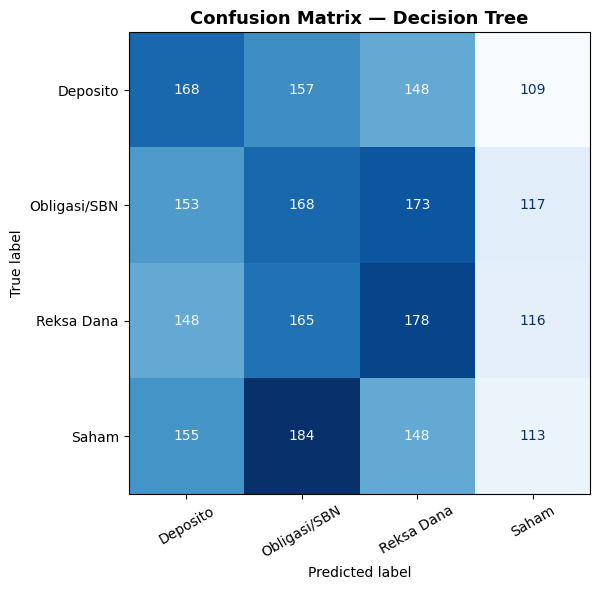

In [6]:
# ================================================
# CELL 3 — MODEL 1: DECISION TREE (BASELINE)
# ================================================
print("🌳 Training Decision Tree...")

dt_model = DecisionTreeClassifier(
    max_depth=10,       # batasi kedalaman pohon
    min_samples_split=5,
    random_state=42
)

dt_model.fit(X_train, y_train)
print("✅ Training selesai!")

# Evaluasi
hasil_dt = evaluasi_model(
    "Decision Tree",
    dt_model,
    X_test,
    y_test
)

# Confusion Matrix
labels = ['Deposito', 'Obligasi/SBN', 'Reksa Dana', 'Saham']
plot_confusion_matrix(
    "Decision Tree",
    y_test,
    hasil_dt['y_pred'],
    labels
)

🌲 Training Random Forest...
✅ Training selesai!
  📊 HASIL EVALUASI: Random Forest
  Accuracy  : 0.2562  (25.62%)
  Precision : 0.2556 (25.56%)
  Recall    : 0.2562  (25.62%)
  F1-Score  : 0.2554  (25.54%)

Classification Report:
              precision    recall  f1-score   support

           0       0.24      0.20      0.22       582
           1       0.26      0.27      0.26       611
           2       0.27      0.28      0.28       607
           3       0.25      0.27      0.26       600

    accuracy                           0.26      2400
   macro avg       0.26      0.26      0.26      2400
weighted avg       0.26      0.26      0.26      2400



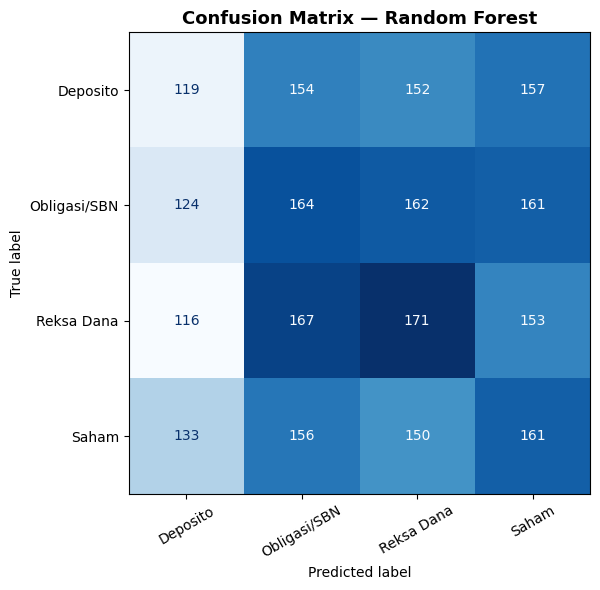

In [7]:
# ================================================
# CELL 4 — MODEL 2: RANDOM FOREST (MODEL UTAMA)
# ================================================
print("🌲 Training Random Forest...")

rf_model = RandomForestClassifier(
    n_estimators=100,   # jumlah pohon
    max_depth=10,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1           # pakai semua core CPU
)

rf_model.fit(X_train, y_train)
print("✅ Training selesai!")

# Evaluasi
hasil_rf = evaluasi_model(
    "Random Forest",
    rf_model,
    X_test,
    y_test
)

# Confusion Matrix
plot_confusion_matrix(
    "Random Forest",
    y_test,
    hasil_rf['y_pred'],
    labels
)

⚡ Training XGBoost...
✅ Training selesai!
  📊 HASIL EVALUASI: XGBoost
  Accuracy  : 0.2492  (24.92%)
  Precision : 0.2494 (24.94%)
  Recall    : 0.2492  (24.92%)
  F1-Score  : 0.2483  (24.83%)

Classification Report:
              precision    recall  f1-score   support

           0       0.26      0.20      0.23       582
           1       0.25      0.29      0.27       611
           2       0.24      0.25      0.25       607
           3       0.25      0.25      0.25       600

    accuracy                           0.25      2400
   macro avg       0.25      0.25      0.25      2400
weighted avg       0.25      0.25      0.25      2400



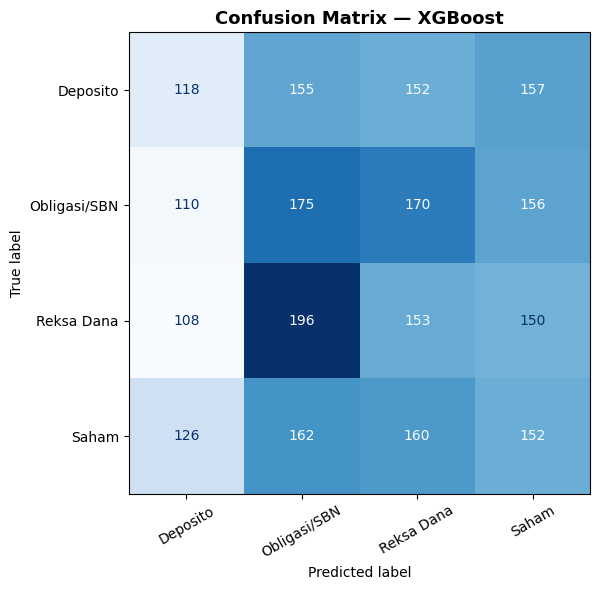

In [8]:
# ================================================
# CELL 5 — MODEL 3: XGBOOST (PEMBANDING)
# ================================================
print("⚡ Training XGBoost...")

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='mlogloss',
    verbosity=0
)

xgb_model.fit(X_train, y_train)
print("✅ Training selesai!")

# Evaluasi
hasil_xgb = evaluasi_model(
    "XGBoost",
    xgb_model,
    X_test,
    y_test
)

# Confusion Matrix
plot_confusion_matrix(
    "XGBoost",
    y_test,
    hasil_xgb['y_pred'],
    labels
)

In [9]:
# ================================================
# CELL 6 — PERBANDINGAN KETIGA MODEL
# ================================================

# Buat tabel perbandingan
hasil_semua = [hasil_dt, hasil_rf, hasil_xgb]

df_hasil = pd.DataFrame([{
    'Model'     : h['model_name'],
    'Accuracy'  : f"{h['accuracy']*100:.2f}%",
    'Precision' : f"{h['precision']*100:.2f}%",
    'Recall'    : f"{h['recall']*100:.2f}%",
    'F1-Score'  : f"{h['f1_score']*100:.2f}%",
} for h in hasil_semua])

print("=" * 60)
print("📊 TABEL PERBANDINGAN MODEL")
print("=" * 60)
display(df_hasil)

# Tentukan model terbaik
model_terbaik = max(hasil_semua,
                    key=lambda x: x['f1_score'])
print(f"\n🏆 Model Terbaik: {model_terbaik['model_name']}")
print(f"   F1-Score: {model_terbaik['f1_score']*100:.2f}%")

📊 TABEL PERBANDINGAN MODEL


,Model,Accuracy,Precision,Recall,F1-Score
0,Decision Tree,26.12%,26.04%,26.12%,25.95%
1,Random Forest,25.62%,25.56%,25.62%,25.54%
2,XGBoost,24.92%,24.94%,24.92%,24.83%



🏆 Model Terbaik: Decision Tree
   F1-Score: 25.95%


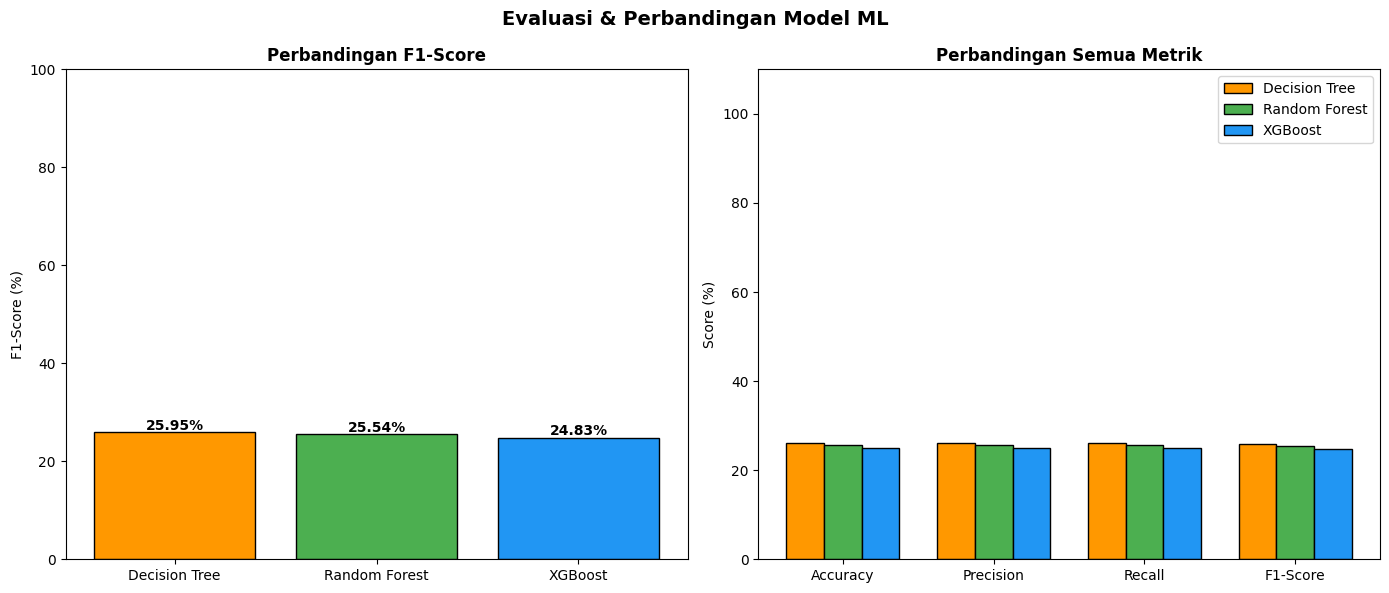

In [10]:
# Visualisasi perbandingan
metrik = ['accuracy', 'precision', 'recall', 'f1_score']
model_names = [h['model_name'] for h in hasil_semua]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Bar chart perbandingan F1-Score
f1_scores = [h['f1_score']*100 for h in hasil_semua]
colors = ['#FF9800', '#4CAF50', '#2196F3']
bars = axes[0].bar(model_names, f1_scores,
                   color=colors, edgecolor='black')
axes[0].set_title('Perbandingan F1-Score', fontweight='bold')
axes[0].set_ylabel('F1-Score (%)')
axes[0].set_ylim(0, 100)
for bar, val in zip(bars, f1_scores):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.5,
                 f'{val:.2f}%', ha='center',
                 fontweight='bold')

# Radar/grouped bar semua metrik
x = np.arange(len(metrik))
width = 0.25
for i, (hasil, color) in enumerate(
        zip(hasil_semua, colors)):
    vals = [hasil[m]*100 for m in metrik]
    axes[1].bar(x + i*width, vals,
                width, label=hasil['model_name'],
                color=color, edgecolor='black')

axes[1].set_title('Perbandingan Semua Metrik',
                  fontweight='bold')
axes[1].set_xticks(x + width)
axes[1].set_xticklabels(
    ['Accuracy', 'Precision', 'Recall', 'F1-Score']
)
axes[1].set_ylabel('Score (%)')
axes[1].set_ylim(0, 110)
axes[1].legend()

plt.suptitle('Evaluasi & Perbandingan Model ML',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../docs/06_perbandingan_model.png',
            dpi=150, bbox_inches='tight')
plt.show()

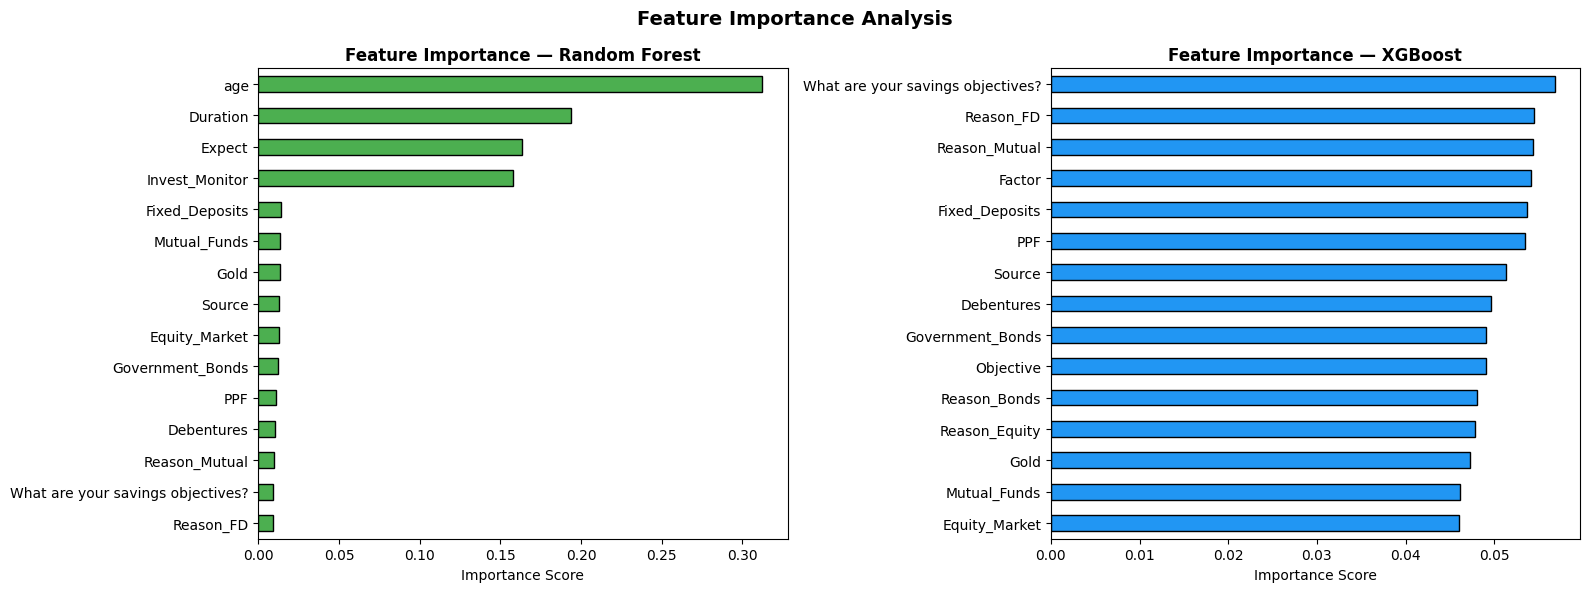


📋 Top 5 Fitur Terpenting (Random Forest):
age               0.312429
Duration          0.193537
Expect            0.163208
Invest_Monitor    0.157941
Fixed_Deposits    0.013769
dtype: float64


In [11]:
# ================================================
# CELL 7 — FEATURE IMPORTANCE
# ================================================
# Fitur mana yang paling penting untuk prediksi?

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Random Forest Feature Importance
feat_imp_rf = pd.Series(
    rf_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=True)

feat_imp_rf.tail(15).plot(
    kind='barh', ax=axes[0],
    color='#4CAF50', edgecolor='black'
)
axes[0].set_title('Feature Importance — Random Forest',
                   fontweight='bold')
axes[0].set_xlabel('Importance Score')

# XGBoost Feature Importance
feat_imp_xgb = pd.Series(
    xgb_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=True)

feat_imp_xgb.tail(15).plot(
    kind='barh', ax=axes[1],
    color='#2196F3', edgecolor='black'
)
axes[1].set_title('Feature Importance — XGBoost',
                   fontweight='bold')
axes[1].set_xlabel('Importance Score')

plt.suptitle('Feature Importance Analysis',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../docs/07_feature_importance.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("\n📋 Top 5 Fitur Terpenting (Random Forest):")
print(feat_imp_rf.sort_values(ascending=False).head())

In [12]:
# ================================================
# CELL 8 — SIMPAN MODEL TERBAIK
# ================================================

os.makedirs('../src/model/saved_model', exist_ok=True)

# Tentukan model final berdasarkan F1-Score terbaik
if model_terbaik['model_name'] == 'Random Forest':
    model_final = rf_model
elif model_terbaik['model_name'] == 'XGBoost':
    model_final = xgb_model
else:
    model_final = dt_model

# Simpan model final
joblib.dump(
    model_final,
    '../src/model/saved_model/investment_model.pkl'
)

# Simpan juga scaler (dari preprocessing)
# joblib.dump(scaler, '../src/model/saved_model/scaler.pkl')

print("✅ Model berhasil disimpan!")
print(f"   Model    : {model_terbaik['model_name']}")
print(f"   F1-Score : {model_terbaik['f1_score']*100:.2f}%")
print(f"   Lokasi   : src/model/saved_model/")

# Verifikasi model bisa di-load kembali
model_loaded = joblib.load(
    '../src/model/saved_model/investment_model.pkl'
)
test_pred = model_loaded.predict(X_test[:5])
print(f"\n✅ Verifikasi model berhasil!")
print(f"   Sample prediksi: {test_pred}")

✅ Model berhasil disimpan!
   Model    : Decision Tree
   F1-Score : 25.95%
   Lokasi   : src/model/saved_model/

✅ Verifikasi model berhasil!
   Sample prediksi: [0 0 2 0 3]


In [13]:
# ================================================
# CELL 9 — RINGKASAN MODELING
# ================================================

print("=" * 60)
print("📋 RINGKASAN TAHAP MODELING")
print("=" * 60)
print(f"""
🤖 MODEL YANG DIEKSPERIMEN:
   1. Decision Tree  → F1: {hasil_dt['f1_score']*100:.2f}%
   2. Random Forest  → F1: {hasil_rf['f1_score']*100:.2f}%
   3. XGBoost        → F1: {hasil_xgb['f1_score']*100:.2f}%

🏆 MODEL TERBAIK:
   Nama     : {model_terbaik['model_name']}
   Accuracy : {model_terbaik['accuracy']*100:.2f}%
   F1-Score : {model_terbaik['f1_score']*100:.2f}%

💾 OUTPUT:
   ✅ Model tersimpan di saved_model/
   ✅ Grafik perbandingan tersimpan di docs/
   ✅ Feature importance tersimpan di docs/

📌 NEXT STEP:
   → Implementasi SHAP untuk transparansi
   → Bangun KBS Rule Engine
""")
print("=" * 60)
print("✅ MODELING SELESAI! Siap ke tahap SHAP! 🚀")
print("=" * 60)

📋 RINGKASAN TAHAP MODELING

🤖 MODEL YANG DIEKSPERIMEN:
   1. Decision Tree  → F1: 25.95%
   2. Random Forest  → F1: 25.54%
   3. XGBoost        → F1: 24.83%

🏆 MODEL TERBAIK:
   Nama     : Decision Tree
   Accuracy : 26.12%
   F1-Score : 25.95%

💾 OUTPUT:
   ✅ Model tersimpan di saved_model/
   ✅ Grafik perbandingan tersimpan di docs/
   ✅ Feature importance tersimpan di docs/

📌 NEXT STEP:
   → Implementasi SHAP untuk transparansi
   → Bangun KBS Rule Engine

✅ MODELING SELESAI! Siap ke tahap SHAP! 🚀


In [ ]:
# Jalankan ini sebagai cell baru (Cell 11)
# di 03_modeling.ipynb

print("=== CROSSCHECK MODELING ===\n")

print("CHECK 1: Akurasi Model")
print("-" * 40)
print(f"Decision Tree  : {hasil_dt['accuracy']*100:.2f}%")
print(f"Random Forest  : {hasil_rf['accuracy']*100:.2f}%")
print(f"XGBoost        : {hasil_xgb['accuracy']*100:.2f}%")

# Validasi rentang akurasi
for nama, hasil in [("Decision Tree", hasil_dt),
                     ("Random Forest", hasil_rf),
                     ("XGBoost", hasil_xgb)]:
    acc = hasil['accuracy'] * 100
    if acc > 99:
        print(f"⚠️  {nama}: Terlalu tinggi → OVERFITTING!")
    elif acc < 30:
        print(f"⚠️  {nama}: Terlalu rendah → Model tidak belajar!")
    else:
        print(f"✅  {nama}: Akurasi wajar!")

=== CROSSCHECK MODELING ===

CHECK 1: Akurasi Model
----------------------------------------
Decision Tree  : 26.12%
Random Forest  : 25.62%
XGBoost        : 24.92%
⚠️  Decision Tree: Terlalu rendah → Model tidak belajar!
⚠️  Random Forest: Terlalu rendah → Model tidak belajar!
⚠️  XGBoost: Terlalu rendah → Model tidak belajar!
